# E-Commerce Customer Segmentation (RFM) & Market Basket Analysis

---

**Author:** Raditya Zaki Athaya  
**Notebook:** `01_data_cleaning_eda.ipynb` — Data Cleaning & Exploratory Data Analysis

---

## Project Overview

Proyek ini bertujuan untuk mengubah data mentah transaksi e-commerce menjadi *actionable insights* yang dapat mendukung keputusan bisnis secara langsung. Analisis dibagi menjadi dua tahap utama:

1. **RFM Analysis:** Melakukan segmentasi pelanggan berdasarkan perilaku transaksi (*Recency, Frequency, Monetary*) untuk membantu tim marketing merancang kampanye retensi yang lebih personal dan efisien.
2. **Market Basket Analysis:** Mengidentifikasi asosiasi antar produk yang sering dibeli bersamaan untuk mengoptimalkan strategi *cross-selling* dan penempatan inventaris.

Notebook ini adalah **tahap pertama** yang fokus pada pembersihan data dan pemahaman awal terhadap dataset sebelum analisis lanjutan dilakukan.

## 1. Import Library & Load Data

Memuat semua library yang dibutuhkan dan melakukan *initial inspection* terhadap dataset. Langkah ini penting untuk memahami struktur data sebelum melakukan transformasi apapun.

**Dataset:** `ecommerce.csv` — berisi data transaksi e-commerce dengan 8 kolom:
`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`.

In [1]:
# ── Standard Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# ── Global Config ────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')                         # suppress non-critical warnings
pd.set_option('display.float_format', '{:,.2f}'.format)  # format angka float
sns.set_theme(style='whitegrid', palette='muted')         # consistent plot style

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ── Load Raw Dataset ─────────────────────────────────────────────────────────
RAW_PATH = '../data/raw/ecommerce.csv'

df = pd.read_csv(
    RAW_PATH,
    encoding='ISO-8859-1',              # encoding umum untuk dataset UK-based e-commerce
    dtype={'CustomerID': str,           # baca sebagai string agar aman saat filtering
           'InvoiceNo': str}
)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("-" * 50)

# Tampilkan 5 baris pertama
df.head()

Dataset loaded: 541,909 rows x 8 columns
--------------------------------------------------


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [3]:
# ── Dataset Info ─────────────────────────────────────────────────────────────
print("=" * 55)
print(" DATASET INFO")
print("=" * 55)
df.info()

# ── Missing Value Summary ────────────────────────────────────────────────────
print("\n" + "=" * 55)
print(" MISSING VALUES PER COLUMN")
print("=" * 55)
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})
print(missing_summary[missing_summary['Missing Count'] > 0])

# ── Descriptive Statistics ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print(" DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe()

 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB

 MISSING VALUES PER COLUMN
             Missing Count  Missing (%)
Description           1454         0.27
CustomerID          135080        24.93

 DESCRIPTIVE STATISTICS


,Quantity,UnitPrice
count,"541,909.00","541,909.00"
mean,9.55,4.61
std,218.08,96.76
min,"-80,995.00","-11,062.06"
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,"80,995.00","38,970.00"


## 2. Data Cleaning

Kualitas data adalah fondasi dari analisis yang valid. Langkah-langkah yang dilakukan:

1. **Hapus baris tanpa `CustomerID`** — transaksi tanpa ID pelanggan tidak bisa digunakan untuk RFM Analysis.
2. **Buang transaksi dibatalkan** — invoice dengan prefix `'C'` menandakan *cancellation*, bukan transaksi nyata.
3. **Filter nilai ≤ 0** — `Quantity` dan `UnitPrice` yang negatif atau nol tidak masuk akal secara bisnis.
4. **Hapus duplikat** — baris duplikat dapat mengakibatkan bias pada hasil agregasi.

In [4]:
# ── Step 1: Hapus Baris dengan CustomerID Kosong ─────────────────────────────
# Tanpa CustomerID, kita tidak bisa melacak perilaku pelanggan untuk RFM
rows_before = len(df)

df = df.dropna(subset=['CustomerID'])

print(f"Baris dihapus (missing CustomerID) : {rows_before - len(df):,}")
print(f"Baris tersisa                       : {len(df):,}")

Baris dihapus (missing CustomerID) : 135,080
Baris tersisa                       : 406,829


In [5]:
# ── Step 2: Buang Transaksi Pembatalan (prefix 'C') ──────────────────────────
rows_before = len(df)

cancelled_mask = df['InvoiceNo'].str.startswith('C', na=False)
df = df[~cancelled_mask]

print(f"Transaksi dibatalkan dibuang        : {rows_before - len(df):,}")

# ── Step 3: Filter Quantity dan UnitPrice yang Tidak Valid ───────────────────
rows_before = len(df)

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(f"Baris Quantity/UnitPrice ≤ 0 dibuang: {rows_before - len(df):,}")

# ── Step 4: Hapus Duplikat ───────────────────────────────────────────────────
rows_before = len(df)
df = df.drop_duplicates()

print(f"Baris duplikat dibuang              : {rows_before - len(df):,}")
print("-" * 45)
print(f"Total baris setelah cleaning        : {len(df):,}")

Transaksi dibatalkan dibuang        : 8,905
Baris Quantity/UnitPrice ≤ 0 dibuang: 40
Baris duplikat dibuang              : 5,192
---------------------------------------------
Total baris setelah cleaning        : 392,692


## 3. Feature Engineering & Tipe Data

Memastikan tipe data sudah tepat dan membuat fitur turunan yang dibutuhkan pada analisis berikutnya:

- **`InvoiceDate`** → dikonversi ke `datetime` agar bisa dihitung selisih waktu untuk *Recency*.
- **`TotalSpend`** (`Quantity × UnitPrice`) → nilai moneter per baris transaksi, dasar perhitungan *Monetary* pada RFM.
- **Fitur waktu tambahan** (`Year`, `Month`, `DayOfWeek`, `Hour`) → berguna untuk analisis tren dan pola temporal di EDA.

In [6]:
# ── Konversi InvoiceDate ke Tipe Datetime ────────────────────────────────────
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], infer_datetime_format=True)

# ── Buat Kolom TotalSpend ────────────────────────────────────────────────────
# TotalSpend = nilai pendapatan per baris transaksi
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# ── Ekstraksi Fitur Waktu ────────────────────────────────────────────────────
df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour']      = df['InvoiceDate'].dt.hour

print("Feature engineering selesai.")
print(f"\nRentang tanggal transaksi:")
print(f"  Mulai  : {df['InvoiceDate'].min()}")
print(f"  Selesai: {df['InvoiceDate'].max()}")
print(f"\nTotal revenue keseluruhan: £{df['TotalSpend'].sum():,.2f}")

df[['InvoiceDate', 'Quantity', 'UnitPrice', 'TotalSpend']].head()

Feature engineering selesai.

Rentang tanggal transaksi:
  Mulai  : 2010-12-01 08:26:00
  Selesai: 2011-12-09 12:50:00

Total revenue keseluruhan: £8,887,208.89


,InvoiceDate,Quantity,UnitPrice,TotalSpend
0,2010-12-01 08:26:00,6,2.55,15.30
1,2010-12-01 08:26:00,6,3.39,20.34
2,2010-12-01 08:26:00,8,2.75,22.00
3,2010-12-01 08:26:00,6,3.39,20.34
4,2010-12-01 08:26:00,6,3.39,20.34


## 4. Exploratory Data Analysis (EDA)

Eksplorasi awal untuk memahami pola distribusi data. EDA ini menjawab beberapa pertanyaan bisnis dasar:

- Negara mana yang menghasilkan pendapatan terbesar?
- Bagaimana tren penjualan dari waktu ke waktu?
- Produk apa yang paling banyak terjual?
- Di jam berapa transaksi paling ramai terjadi?

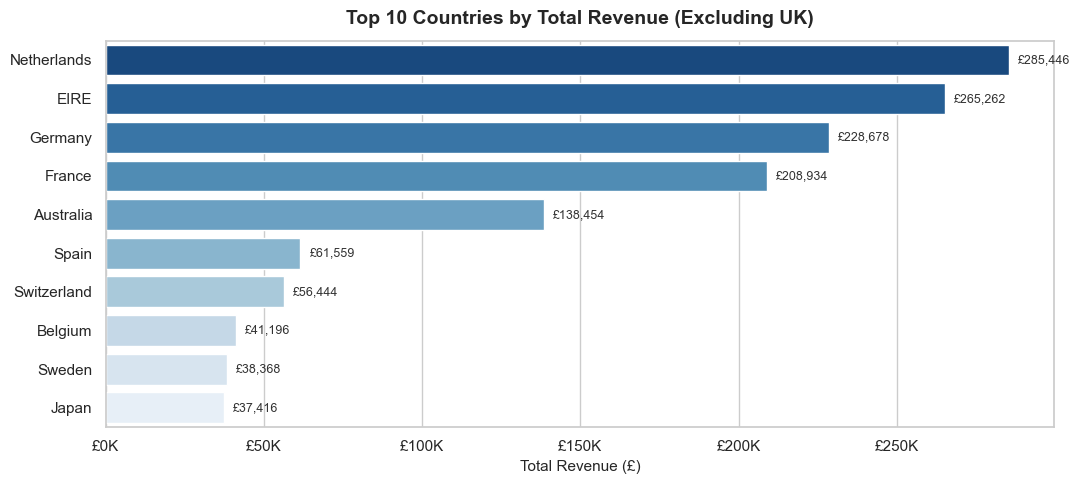

In [7]:
# ── Top 10 Negara berdasarkan Total Pendapatan ───────────────────────────────
# UK di-exclude karena sangat dominan dan menyembunyikan variasi negara lain
top_countries = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country', as_index=False)['TotalSpend']
    .sum()
    .sort_values('TotalSpend', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(data=top_countries, x='TotalSpend', y='Country',
            palette='Blues_r', ax=ax)

# Tambahkan label nilai di ujung setiap bar
for bar in ax.patches:
    ax.text(
        bar.get_width() + top_countries['TotalSpend'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"£{bar.get_width():,.0f}",
        va='center', fontsize=9, color='#333333'
    )

ax.set_title('Top 10 Countries by Total Revenue (Excluding UK)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Revenue (£)', fontsize=11)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

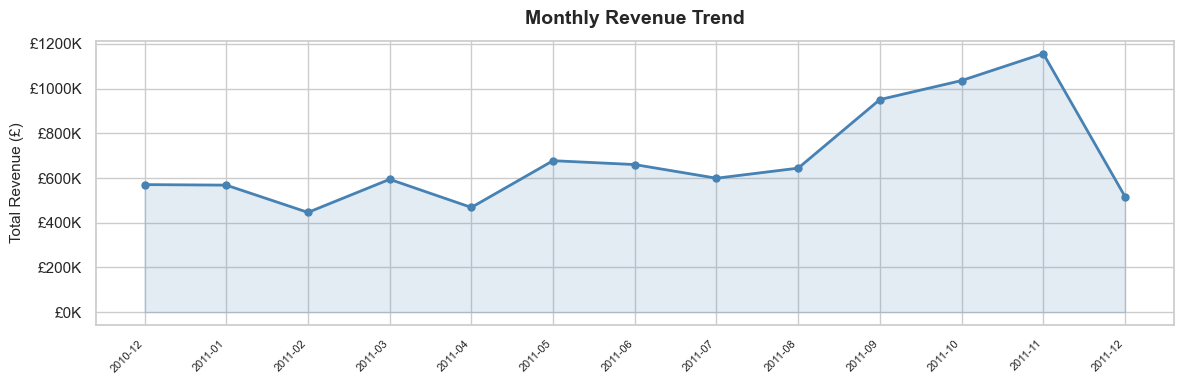

In [8]:
# ── Tren Pendapatan Bulanan ───────────────────────────────────────────────────
monthly_revenue = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalSpend']
    .sum()
    .reset_index()
)
monthly_revenue['InvoiceDate'] = monthly_revenue['InvoiceDate'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(range(len(monthly_revenue)), monthly_revenue['TotalSpend'],
                alpha=0.15, color='steelblue')
ax.plot(range(len(monthly_revenue)), monthly_revenue['TotalSpend'],
        marker='o', color='steelblue', linewidth=2, markersize=5)

ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['InvoiceDate'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Revenue (£)', fontsize=11)

plt.tight_layout()
plt.show()

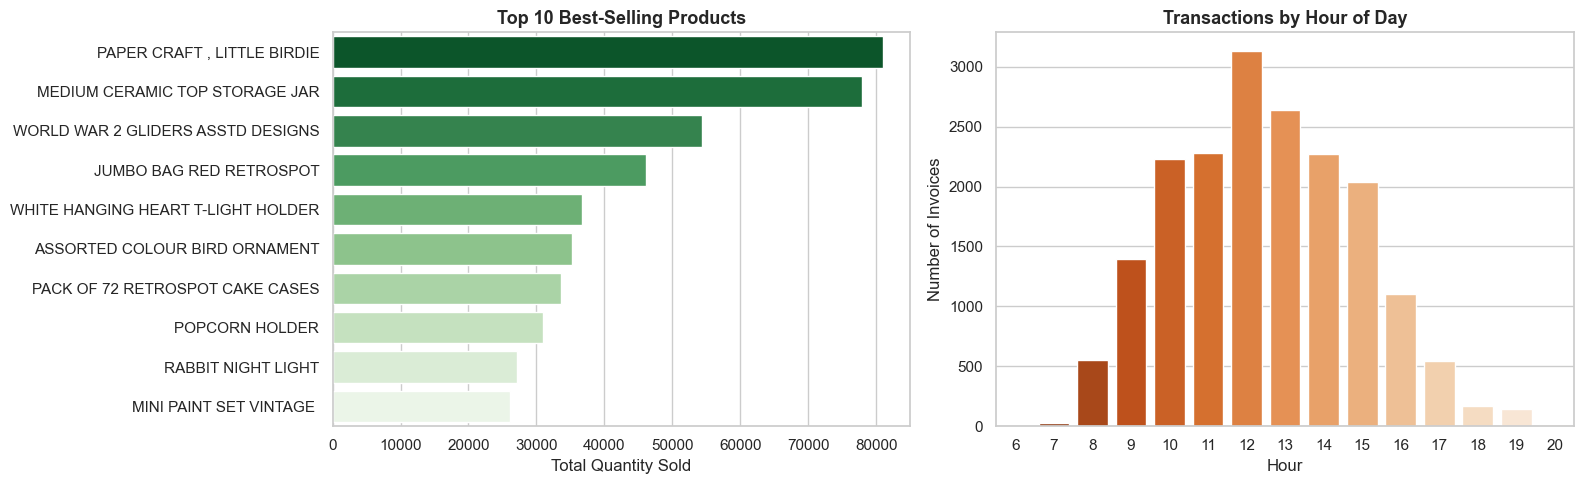


── EDA Summary ──────────────────────────────────────────
  Total unique customers : 4,338
  Total unique invoices  : 18,532
  Total unique products  : 3,665
  Total unique countries : 37
  Gross revenue          : £8,887,208.89


In [9]:
# ── Top 10 Produk Terlaris (by Quantity) ─────────────────────────────────────
top_products = (
    df.groupby('Description', as_index=False)['Quantity']
    .sum()
    .sort_values('Quantity', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot kiri: top products
sns.barplot(data=top_products, x='Quantity', y='Description',
            palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 10 Best-Selling Products', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Quantity Sold')
axes[0].set_ylabel('')

# Plot kanan: transaksi per jam
hourly = df.groupby('Hour')['InvoiceNo'].nunique().reset_index()
hourly.columns = ['Hour', 'NumTransactions']

sns.barplot(data=hourly, x='Hour', y='NumTransactions',
            palette='Oranges_r', ax=axes[1])
axes[1].set_title('Transactions by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Invoices')

plt.tight_layout()
plt.show()

# ── EDA Summary Stats ────────────────────────────────────────────────────────
print("\n── EDA Summary ──────────────────────────────────────────")
print(f"  Total unique customers : {df['CustomerID'].nunique():,}")
print(f"  Total unique invoices  : {df['InvoiceNo'].nunique():,}")
print(f"  Total unique products  : {df['StockCode'].nunique():,}")
print(f"  Total unique countries : {df['Country'].nunique():,}")
print(f"  Gross revenue          : £{df['TotalSpend'].sum():,.2f}")